Este notebook tiene como fin visualizar los datos de la tarea 02, correspondientes a la auditoría energética de consumo del edificio Chamchuri - Planta 3.

En primer lugar, vamos a cargar las librerías que vamos a utilizar: 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import matplotlib.pyplot as plt

A continuación, creamos los DataFrames con las dos fuentes de datos (una para cada año): 

In [2]:
df1 = pd.read_csv("2018Floor3.csv/2018Floor3.csv")
df2 = pd.read_csv("2019Floor3.csv/2019Floor3.csv")

Vamos a juntar los dos dataframes en uno solo para trabajar de manera mas precisa:

In [3]:
df = pd.concat([df1,df2], ignore_index=True)

Echamos un vistazo rápido a los datos:

In [4]:
df.head()

,Date,z1_AC1(kW),z1_AC2(kW),z1_AC3(kW),z1_AC4(kW),z1_Light(kW),z1_Plug(kW),z1_S1(degC),z1_S1(RH%),z1_S1(lux),...,z4_Plug(kW),z4_S1(degC),z4_S1(RH%),z4_S1(lux),z5_AC1(kW),z5_Light(kW),z5_Plug(kW),z5_S1(degC),z5_S1(RH%),z5_S1(lux)
0,2018-07-01 00:00:00,0.0,0.0,0.0,0.07,0.0,0.03,28.44,60.67,0.0,...,0.02,27.69,65.66,0.0,0.0,0.0,0.02,26.88,71.16,0.0
1,2018-07-01 00:01:00,0.0,0.0,0.0,0.07,0.0,0.03,28.44,60.67,0.0,...,0.02,27.69,65.65,0.0,0.0,0.0,0.02,26.88,71.16,0.0
2,2018-07-01 00:02:00,0.0,0.0,0.0,0.07,0.0,0.03,28.45,60.67,0.0,...,0.02,27.69,65.63,0.0,0.0,0.0,0.02,26.88,71.18,0.0
3,2018-07-01 00:03:00,0.0,0.0,0.0,0.07,0.0,0.03,28.45,60.66,0.0,...,0.02,NaN,NaN,NaN,0.0,0.0,0.02,26.88,71.19,0.0
4,2018-07-01 00:04:00,0.0,0.0,0.0,0.07,0.0,0.03,28.45,60.66,0.0,...,0.02,NaN,NaN,NaN,0.0,0.0,0.02,26.88,71.21,0.0


In [5]:
df.tail()

,Date,z1_AC1(kW),z1_AC2(kW),z1_AC3(kW),z1_AC4(kW),z1_Light(kW),z1_Plug(kW),z1_S1(degC),z1_S1(RH%),z1_S1(lux),...,z4_Plug(kW),z4_S1(degC),z4_S1(RH%),z4_S1(lux),z5_AC1(kW),z5_Light(kW),z5_Plug(kW),z5_S1(degC),z5_S1(RH%),z5_S1(lux)
790555,2019-12-31 23:55:00,0.0,0.0,0.0,0.0,0.0,0.05,26.98,63.5,0.0,...,0.03,26.69,66.89,0.0,0.0,0.0,0.03,27.24,64.82,0.0
790556,2019-12-31 23:56:00,0.0,0.0,0.0,0.0,0.0,0.05,26.97,63.6,0.0,...,0.03,26.68,66.89,0.0,0.0,0.0,0.04,27.23,64.81,0.0
790557,2019-12-31 23:57:00,0.0,0.0,0.0,0.0,0.0,0.05,26.97,63.5,0.0,...,0.03,26.67,66.91,0.0,0.0,0.0,0.04,27.24,64.80,0.0
790558,2019-12-31 23:58:00,0.0,0.0,0.0,0.0,0.0,0.05,26.97,63.4,0.0,...,0.03,26.68,66.89,0.0,0.0,0.0,0.04,27.24,64.80,0.0
790559,2019-12-31 23:59:00,0.0,0.0,0.0,0.0,0.0,0.05,26.98,63.6,0.0,...,0.03,26.68,66.91,0.0,0.0,0.0,0.04,27.22,64.79,0.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 790560 entries, 0 to 790559
Data columns (total 30 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Date          790560 non-null  str    
 1   z1_AC1(kW)    719633 non-null  float64
 2   z1_AC2(kW)    719633 non-null  float64
 3   z1_AC3(kW)    719633 non-null  float64
 4   z1_AC4(kW)    687770 non-null  float64
 5   z1_Light(kW)  730710 non-null  float64
 6   z1_Plug(kW)   730827 non-null  float64
 7   z1_S1(degC)   498458 non-null  float64
 8   z1_S1(RH%)    498456 non-null  float64
 9   z1_S1(lux)    498453 non-null  float64
 10  z2_AC1(kW)    687781 non-null  float64
 11  z2_Light(kW)  729811 non-null  float64
 12  z2_Plug(kW)   730808 non-null  float64
 13  z2_S1(degC)   516157 non-null  float64
 14  z2_S1(RH%)    516153 non-null  float64
 15  z2_S1(lux)    516156 non-null  float64
 16  z3_Light(kW)  730799 non-null  float64
 17  z3_Plug(kW)   730757 non-null  float64
 18  z4_AC1(kW)    6

Nos vamos a quedar solo con los datos que nos hacen falta:

In [7]:
df = df[['Date','z1_AC1(kW)','z1_AC2(kW)','z1_AC3(kW)','z1_AC4(kW)','z1_Light(kW)','z1_Plug(kW)','z2_AC1(kW)','z2_Light(kW)','z2_Plug(kW)','z3_Light(kW)','z3_Plug(kW)'
        ,'z4_AC1(kW)','z4_Light(kW)','z4_Plug(kW)','z5_AC1(kW)','z5_Light(kW)','z5_Plug(kW)']]

Vemos que la columna Date la trata como String, si queremos operar con esta necesitamos convertirla a tipo Datetime:

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 790560 entries, 0 to 790559
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Date          790560 non-null  datetime64[us]
 1   z1_AC1(kW)    719633 non-null  float64       
 2   z1_AC2(kW)    719633 non-null  float64       
 3   z1_AC3(kW)    719633 non-null  float64       
 4   z1_AC4(kW)    687770 non-null  float64       
 5   z1_Light(kW)  730710 non-null  float64       
 6   z1_Plug(kW)   730827 non-null  float64       
 7   z2_AC1(kW)    687781 non-null  float64       
 8   z2_Light(kW)  729811 non-null  float64       
 9   z2_Plug(kW)   730808 non-null  float64       
 10  z3_Light(kW)  730799 non-null  float64       
 11  z3_Plug(kW)   730757 non-null  float64       
 12  z4_AC1(kW)    687784 non-null  float64       
 13  z4_Light(kW)  726489 non-null  float64       
 14  z4_Plug(kW)   729259 non-null  float64       
 15  z5_AC1(kW)    687788 non-nul

Comprobamos cuantos valores vacíos tenemos en el DataFrame: 

In [10]:
df.isnull().sum()

Date                 0
z1_AC1(kW)       70927
z1_AC2(kW)       70927
z1_AC3(kW)       70927
z1_AC4(kW)      102790
z1_Light(kW)     59850
z1_Plug(kW)      59733
z2_AC1(kW)      102779
z2_Light(kW)     60749
z2_Plug(kW)      59752
z3_Light(kW)     59761
z3_Plug(kW)      59803
z4_AC1(kW)      102776
z4_Light(kW)     64071
z4_Plug(kW)      61301
z5_AC1(kW)      102772
z5_Light(kW)     64071
z5_Plug(kW)      59831
dtype: int64

Como podemos observar, tenemos datos nulos en todas las columnas. Debemos tratar cada una de manera concreta para no infundir en errores. 

Los datos relativos a los sensores son los que mas valores nulos tienen, pero estos no los vamos a usar para nuestro estudio.

Por otro lado, para las demás columnas lo que vamos a hacer es sustituir por la media de consumo a esa hora: 

In [11]:
meses = df['Date'].dt.month

print(meses.unique())

[ 7  8  9 10 11 12  1  2  3  4  5  6]


In [12]:
# kw_cols = [c for c in df.columns if "kw" in c]

# for col in kw_cols: 
    # df[col] = df[col].fillna(df.groupby('Hour')[col].transform('mean'))

df = df.dropna()

Ya que el DataFrame parece que está correcto, vamos a realizar la primera tarea. 

Consumo promedio de cada zona de cada hora del día:

En primer lugar vamos a sacar una columna que nos devuelva solo la hora de la columna Date, para poder agrupar por esta:

In [13]:
df['Hour'] = df['Date'].dt.hour
df['DateOnly'] = df['Date'].dt.date 
df['YearMonth'] = df['Date'].dt.to_period('M')

Ahora agrupamos las columnas para tener la suma del consumo de toda una zona:

In [14]:
df['TotalZ1'] = df[['z1_AC1(kW)','z1_AC2(kW)','z1_AC3(kW)','z1_AC4(kW)','z1_Light(kW)','z1_Plug(kW)']].sum(axis=1)
df['TotalZ2'] = df[['z2_AC1(kW)','z2_Light(kW)','z2_Plug(kW)']].sum(axis=1)
df['TotalZ3'] = df[['z3_Light(kW)','z3_Plug(kW)']].sum(axis=1)
df['TotalZ4'] = df[['z4_AC1(kW)','z4_Light(kW)','z4_Plug(kW)']].sum(axis=1)
df['TotalZ5'] = df[['z5_AC1(kW)','z5_Light(kW)','z5_Plug(kW)']].sum(axis=1)

In [15]:
df.head()

,Date,z1_AC1(kW),z1_AC2(kW),z1_AC3(kW),z1_AC4(kW),z1_Light(kW),z1_Plug(kW),z2_AC1(kW),z2_Light(kW),z2_Plug(kW),...,z5_Light(kW),z5_Plug(kW),Hour,DateOnly,YearMonth,TotalZ1,TotalZ2,TotalZ3,TotalZ4,TotalZ5
0,2018-07-01 00:00:00,0.0,0.0,0.0,0.07,0.0,0.03,0.0,0.0,0.03,...,0.0,0.02,0,2018-07-01,2018-07,0.1,0.03,0.27,0.02,0.02
1,2018-07-01 00:01:00,0.0,0.0,0.0,0.07,0.0,0.03,0.0,0.0,0.03,...,0.0,0.02,0,2018-07-01,2018-07,0.1,0.03,0.39,0.02,0.02
2,2018-07-01 00:02:00,0.0,0.0,0.0,0.07,0.0,0.03,0.0,0.0,0.03,...,0.0,0.02,0,2018-07-01,2018-07,0.1,0.03,0.33,0.02,0.02
3,2018-07-01 00:03:00,0.0,0.0,0.0,0.07,0.0,0.03,0.0,0.0,0.03,...,0.0,0.02,0,2018-07-01,2018-07,0.1,0.03,0.27,0.02,0.02
4,2018-07-01 00:04:00,0.0,0.0,0.0,0.07,0.0,0.03,0.0,0.0,0.03,...,0.0,0.02,0,2018-07-01,2018-07,0.1,0.03,0.39,0.02,0.02


Seleccionamos las columnas que vamos a visualizar: 

In [16]:
selected_cols = df[['TotalZ1','TotalZ2','TotalZ3','TotalZ4','TotalZ5']]

Creamos un gráfico de barras para cada una de estas columnas: 

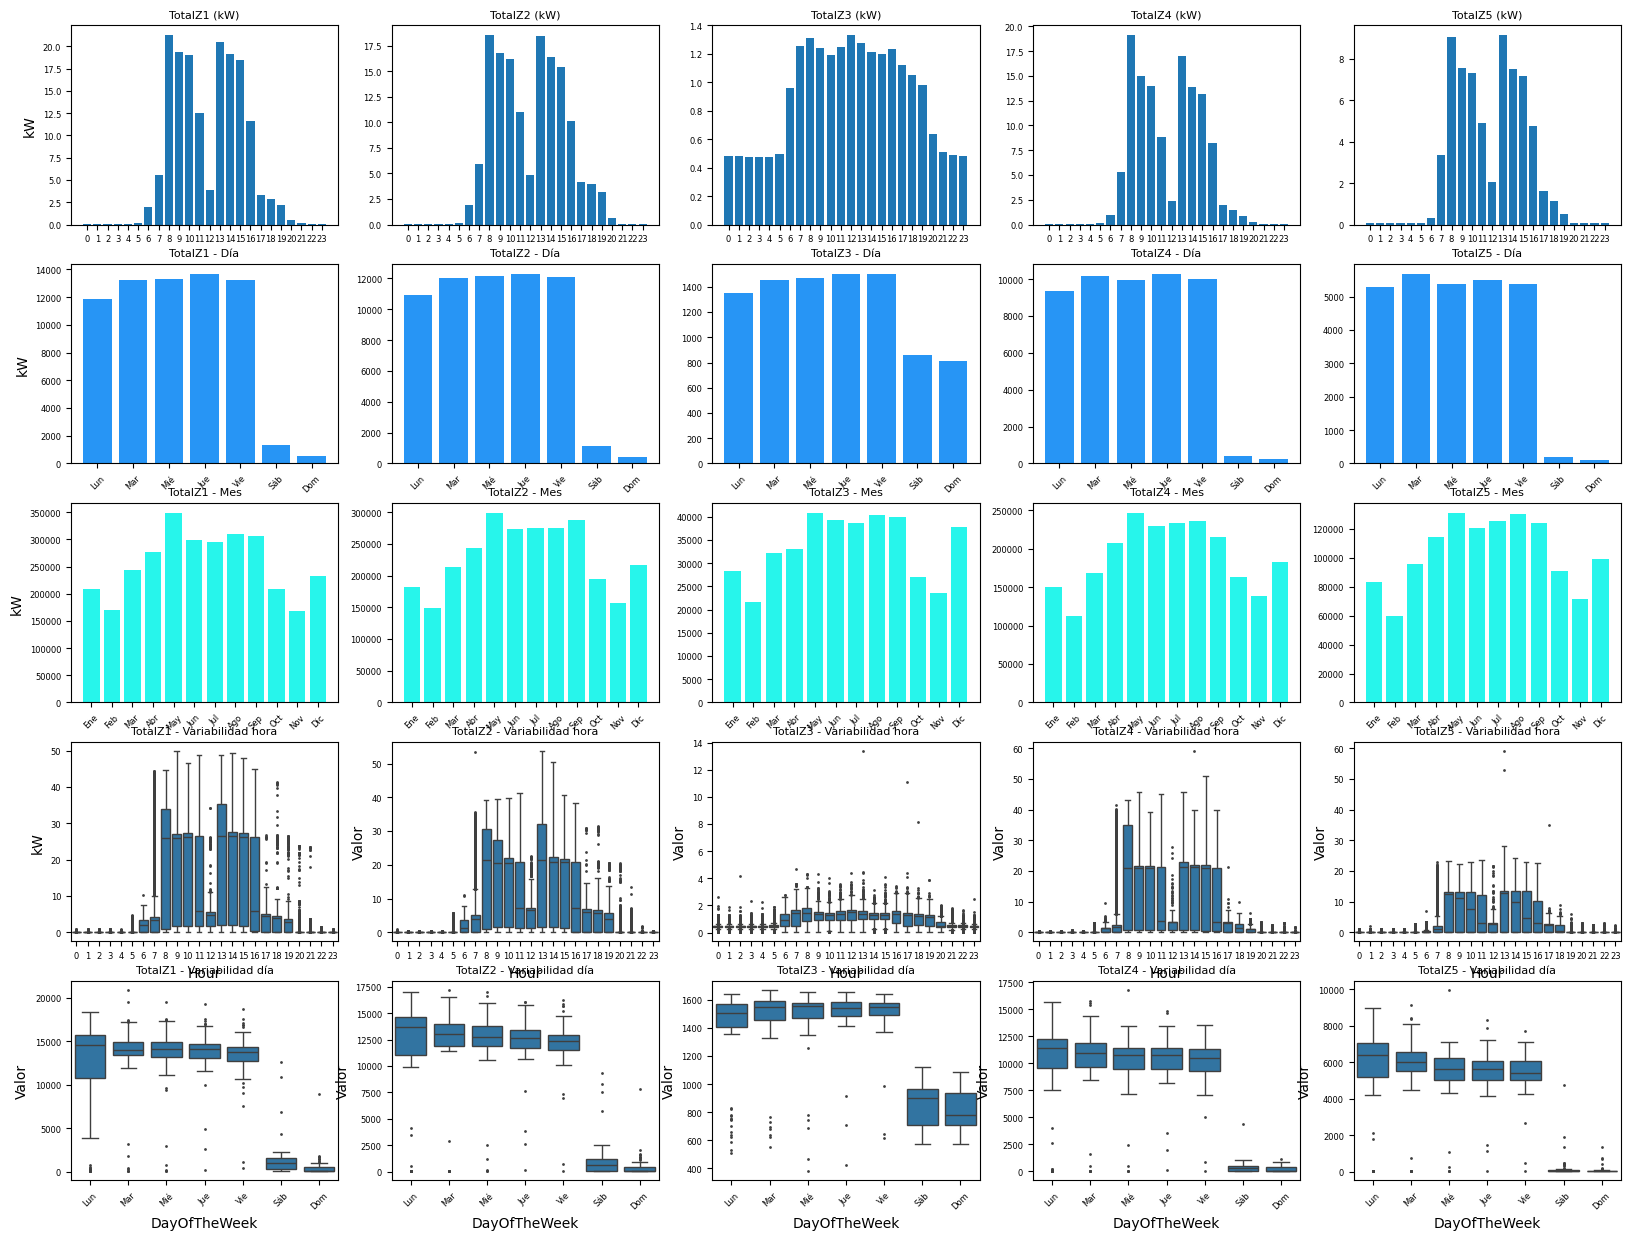

In [17]:
dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"] # Para sustituirlo en el gráfico por el indice de los dias (0,1,2..)
meses = ["Ene","Feb","Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

# Para que salgan agrupadas las tablas 
n_cols = 5 
n_rows = 1 

total_rows = n_rows * 5

fig, axes = plt.subplots(total_rows, n_cols, figsize=(20, 3 * total_rows))
axes = axes.reshape(total_rows, n_cols)

for i,col in enumerate(selected_cols): 

    row = i // n_cols
    col_pos = i % n_cols

    # Promedio por hora

    hourly_mean = df.groupby('Hour')[col].mean()

    axes[0, col_pos].bar(hourly_mean.index, hourly_mean.values)
    axes[0, col_pos].set_title(col + ' (kW)', fontsize=8)
    axes[0, col_pos].set_xticks(range(0, 24))
    axes[0, col_pos].tick_params(axis='both', labelsize=6)

    if(i == 0):
        axes[0, col_pos].set_ylabel('kW')    

    # Promedio por día de la semana 

    daily_sum = df.groupby('DateOnly')[col].sum() # Primero tenemos que agrupar por suma el dia completo (los datos vienen de hora en hora)
    daily_sum = daily_sum.to_frame()
    daily_sum['DayOfTheWeek'] = pd.to_datetime(daily_sum.index).dayofweek

    weekday_mean = daily_sum.groupby('DayOfTheWeek')[col].mean()

    axes[1, col_pos].bar(range(7), weekday_mean.values, color='#2795F5')
    axes[1, col_pos].set_title(f"{col} - Día", fontsize=8)
    axes[1, col_pos].set_xticks(range(7))
    axes[1, col_pos].set_xticklabels(dias, rotation=45)
    axes[1, col_pos].tick_params(axis='both', labelsize=6)
    if(i == 0):
        axes[1, col_pos].set_ylabel('kW')  

    # Promedio por mes 

    monthly_sum = df.groupby('YearMonth')[col].sum()

    monthly_mean = monthly_sum.groupby(monthly_sum.index.month).mean()
    monthly_mean = monthly_mean.reindex(range(1, 13))

    axes[2, col_pos].bar(range(12), monthly_mean.values, color="#27F5EB")
    axes[2, col_pos].set_title(f"{col} - Mes", fontsize=8)
    axes[2, col_pos].set_xticks(range(12))
    axes[2, col_pos].set_xticklabels(meses, rotation=45)
    axes[2, col_pos].tick_params(axis='both', labelsize=6)
    if(i == 0):
        axes[2, col_pos].set_ylabel('kW')  

    # Variabilidad para hora del día 

    tmp = df[['Hour', col]].rename(columns={col : 'Valor'})

    sns.boxplot(
        data = tmp,
        x = 'Hour',
        y = 'Valor',
        ax = axes[3, col_pos],
        fliersize = 1
    )

    axes[3, col_pos].set_title(f"{col} - Variabilidad hora", fontsize=8)
    axes[3, col_pos].set_xticks(range(0, 24))
    axes[3, col_pos].tick_params(axis='both', labelsize=6)

    if i == 0:
        axes[3, col_pos].set_ylabel('kW')

    # Variabilidad para día de la semana 
    
    daily_sum_var = df.groupby('DateOnly')[col].sum().dropna().to_frame(name='Valor')
    daily_sum_var['DayOfTheWeek'] = pd.to_datetime(daily_sum_var.index).dayofweek

    sns.boxplot(
        data = daily_sum_var, 
        x = 'DayOfTheWeek', 
        y = 'Valor',
        ax = axes[4, col_pos], 
        fliersize = 1
    )

    axes[4, col_pos].set_title(f"{col} - Variabilidad día", fontsize=8)
    axes[4, col_pos].set_xticks(range(7))
    axes[4, col_pos].set_xticklabels(dias, rotation=45)
    axes[4, col_pos].tick_params(axis='both', labelsize=6)

plt.show()

Ahora nos vamos a centrar en las gráficas correspondientes al total del piso, sumando todas las zonas:

En primer lugar, debemos agrupar los datos para sumar todas las zonas: 

In [18]:
df.head()

,Date,z1_AC1(kW),z1_AC2(kW),z1_AC3(kW),z1_AC4(kW),z1_Light(kW),z1_Plug(kW),z2_AC1(kW),z2_Light(kW),z2_Plug(kW),...,z5_Light(kW),z5_Plug(kW),Hour,DateOnly,YearMonth,TotalZ1,TotalZ2,TotalZ3,TotalZ4,TotalZ5
0,2018-07-01 00:00:00,0.0,0.0,0.0,0.07,0.0,0.03,0.0,0.0,0.03,...,0.0,0.02,0,2018-07-01,2018-07,0.1,0.03,0.27,0.02,0.02
1,2018-07-01 00:01:00,0.0,0.0,0.0,0.07,0.0,0.03,0.0,0.0,0.03,...,0.0,0.02,0,2018-07-01,2018-07,0.1,0.03,0.39,0.02,0.02
2,2018-07-01 00:02:00,0.0,0.0,0.0,0.07,0.0,0.03,0.0,0.0,0.03,...,0.0,0.02,0,2018-07-01,2018-07,0.1,0.03,0.33,0.02,0.02
3,2018-07-01 00:03:00,0.0,0.0,0.0,0.07,0.0,0.03,0.0,0.0,0.03,...,0.0,0.02,0,2018-07-01,2018-07,0.1,0.03,0.27,0.02,0.02
4,2018-07-01 00:04:00,0.0,0.0,0.0,0.07,0.0,0.03,0.0,0.0,0.03,...,0.0,0.02,0,2018-07-01,2018-07,0.1,0.03,0.39,0.02,0.02


In [19]:
df = df[['Date', 'Hour', 'DateOnly','YearMonth','TotalZ1','TotalZ2','TotalZ3','TotalZ4','TotalZ5']]

df.head()

,Date,Hour,DateOnly,YearMonth,TotalZ1,TotalZ2,TotalZ3,TotalZ4,TotalZ5
0,2018-07-01 00:00:00,0,2018-07-01,2018-07,0.1,0.03,0.27,0.02,0.02
1,2018-07-01 00:01:00,0,2018-07-01,2018-07,0.1,0.03,0.39,0.02,0.02
2,2018-07-01 00:02:00,0,2018-07-01,2018-07,0.1,0.03,0.33,0.02,0.02
3,2018-07-01 00:03:00,0,2018-07-01,2018-07,0.1,0.03,0.27,0.02,0.02
4,2018-07-01 00:04:00,0,2018-07-01,2018-07,0.1,0.03,0.39,0.02,0.02


Ahora que nos hemos quedado solo con los datos necesarios, sumamos todas las columnas de zonas: 

In [20]:
df['TotalPiso'] = df[['TotalZ1','TotalZ2','TotalZ3','TotalZ4','TotalZ5']].sum(axis=1)
df.head()

,Date,Hour,DateOnly,YearMonth,TotalZ1,TotalZ2,TotalZ3,TotalZ4,TotalZ5,TotalPiso
0,2018-07-01 00:00:00,0,2018-07-01,2018-07,0.1,0.03,0.27,0.02,0.02,0.44
1,2018-07-01 00:01:00,0,2018-07-01,2018-07,0.1,0.03,0.39,0.02,0.02,0.56
2,2018-07-01 00:02:00,0,2018-07-01,2018-07,0.1,0.03,0.33,0.02,0.02,0.50
3,2018-07-01 00:03:00,0,2018-07-01,2018-07,0.1,0.03,0.27,0.02,0.02,0.44
4,2018-07-01 00:04:00,0,2018-07-01,2018-07,0.1,0.03,0.39,0.02,0.02,0.56


Generamos ahora las gráficas: 

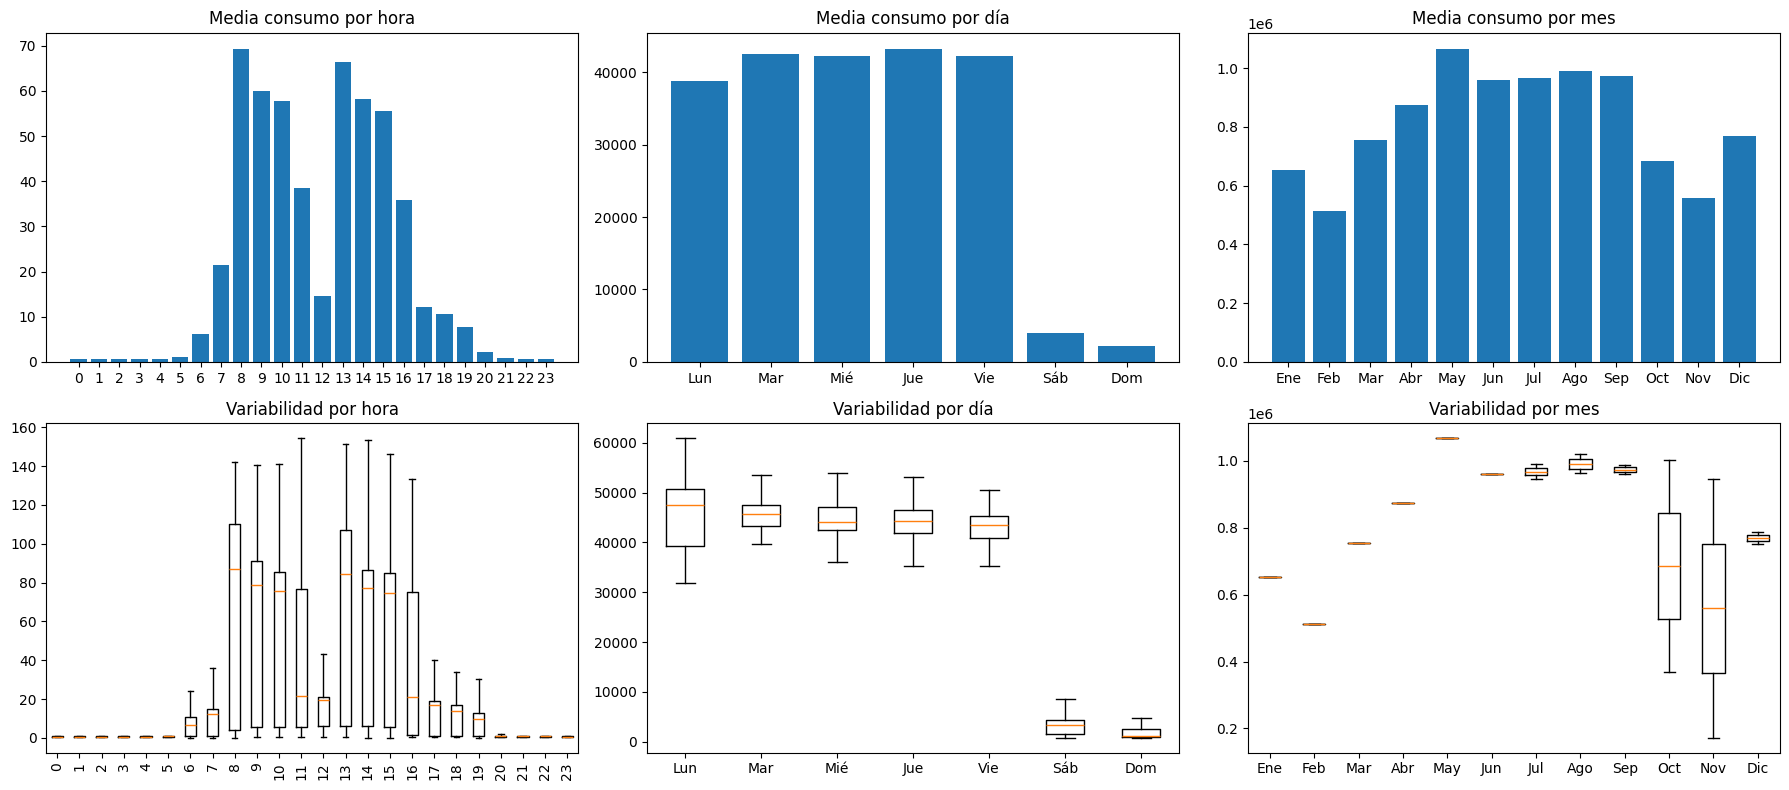

In [22]:
# ---------------- MEDIAS ----------------
media_por_hora = df.groupby('Hour')['TotalPiso'].mean()

df_diario = df.groupby('DateOnly')['TotalPiso'].sum().reset_index()
df_diario['DayOfTheWeek'] = pd.to_datetime(df_diario['DateOnly']).dt.dayofweek
media_por_dia = df_diario.groupby('DayOfTheWeek')['TotalPiso'].mean()

df_mensual = df.groupby(pd.to_datetime(df['DateOnly']).dt.to_period('M'))['TotalPiso'].sum().reset_index()
df_mensual['Month'] = df_mensual['DateOnly'].dt.month
media_por_mes = df_mensual.groupby('Month')['TotalPiso'].mean()

# ---------------- PREPARAR DATOS PARA BOXPLOTS ----------------
df['Month'] = pd.to_datetime(df['DateOnly']).dt.month

# consumo por hora
datos_hora = [df[df['Hour'] == h]['TotalPiso'] for h in range(24)]

# consumo por día (usando suma diaria)
datos_dia = [df_diario[df_diario['DayOfTheWeek'] == d]['TotalPiso'] for d in range(7)]

# consumo por mes (usando suma mensual)
datos_mes = [df_mensual[df_mensual['Month'] == m]['TotalPiso'] for m in range(1,13)]

# ---------------- GRÁFICOS ----------------
fig, axes = plt.subplots(2, 3, figsize=(18,8))

# ----- MEDIAS -----
axes[0,0].bar(media_por_hora.index, media_por_hora.values)
axes[0,0].set_title("Media consumo por hora")
axes[0,0].set_xticks(range(24))

axes[0,1].bar(media_por_dia.index, media_por_dia.values)
axes[0,1].set_title("Media consumo por día")
axes[0,1].set_xticks(range(7))
axes[0,1].set_xticklabels(dias)

axes[0,2].bar(media_por_mes.index-1, media_por_mes.values)
axes[0,2].set_title("Media consumo por mes")
axes[0,2].set_xticks(range(12))
axes[0,2].set_xticklabels(meses)

# ----- BOXPLOTS (VARIABILIDAD) -----
axes[1,0].boxplot(datos_hora, showfliers=False)
axes[1,0].set_title("Variabilidad por hora")
axes[1,0].set_xticks(range(1,25))
axes[1,0].set_xticklabels(range(24), rotation=90)

axes[1,1].boxplot(datos_dia, showfliers=False)
axes[1,1].set_title("Variabilidad por día")
axes[1,1].set_xticks(range(1,8))
axes[1,1].set_xticklabels(dias)

axes[1,2].boxplot(datos_mes, showfliers=False)
axes[1,2].set_title("Variabilidad por mes")
axes[1,2].set_xticks(range(1,13))
axes[1,2].set_xticklabels(meses)

plt.tight_layout()
plt.show()